# Warehouse Conveyor Scheduling — Dispatching-Rule Comparison

Sequence **80 totes** across a **4-lane warehouse conveyor** during a 25-minute rush window. Each tote has a release time (when it arrives at the dispatch point) and a processing time (how long the lane takes to handle it). The decision: when a lane frees up, which waiting tote does it take next?

We compare five classical dispatching rules:

| Rule | Decision when a lane frees up |
|---|---|
| **FIFO** | Take the oldest waiting tote (baseline). |
| **EFT** (Earliest Finish Time) | Pick the (tote, lane) pair that minimises finish time. |
| **SPT** (Shortest Processing Time) | Among ready totes, take the shortest. Provably optimal for makespan when all releases = 0. |
| **LPT** (Longest Processing Time) | Among ready totes, take the longest. Empirically strong on makespan with non-zero releases. |
| **WSPT** (Weighted SPT) | Smith's rule — pick the largest priority/processing ratio. Optimal for weighted-flow-time. |

Output metrics: **makespan** (when the last tote finishes), **mean flow time** (release → finish), **mean wait** (release → start), and **lane-load balance** (CV across lanes).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scheduling import RULES, compare_rules, load_totes

plt.rcParams['figure.dpi'] = 110
pd.options.display.float_format = '{:,.2f}'.format

## 1. Load the workload

In [2]:
totes, num_lanes = load_totes('conveyor_data.xlsx')
df = pd.DataFrame([t.__dict__ for t in totes])
print(f'{len(totes)} totes  ·  {num_lanes} lanes')
print(f'Total work to do:   {df["processing"].sum():,.0f} s ({df["processing"].sum() / num_lanes:,.0f} s/lane on perfect balance)')
print(f'Arrival window:     0 to {df["release"].max():,.0f} s')
df.head()

80 totes  ·  4 lanes
Total work to do:   4,568 s (1,142 s/lane on perfect balance)
Arrival window:     0 to 1,200 s


,tote_id,release,processing,priority,grade
0,T001,34.30,61.00,1,Express
1,T002,34.30,29.10,1,Express
2,T003,57.70,77.90,1,Standard
3,T004,59.40,86.50,2,Standard
4,T005,61.00,17.60,2,Standard


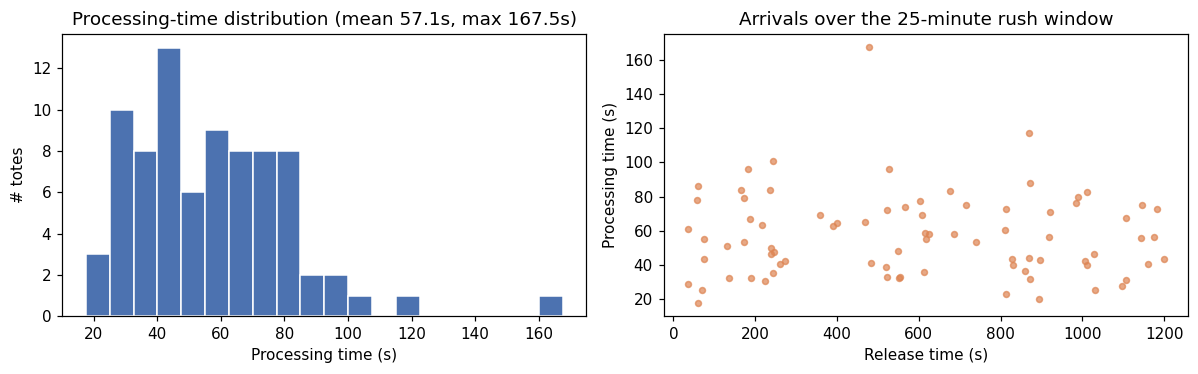

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df['processing'], bins=20, color='#4c72b0', edgecolor='white')
axes[0].set_xlabel('Processing time (s)'); axes[0].set_ylabel('# totes')
axes[0].set_title(f'Processing-time distribution (mean {df["processing"].mean():.1f}s, max {df["processing"].max():.1f}s)')
axes[1].scatter(df['release'], df['processing'], s=15, alpha=0.7, color='#dd8452')
axes[1].set_xlabel('Release time (s)'); axes[1].set_ylabel('Processing time (s)')
axes[1].set_title('Arrivals over the 25-minute rush window')
plt.tight_layout(); plt.show()

## 2. Apply each dispatching rule

In [4]:
summary = compare_rules(totes, num_lanes)
summary

,rule,makespan_s,makespan_h,mean_flow_s,mean_wait_s,lane_balance_cv
0,FIFO,"1,271.80",0.35,86.00,28.90,0.02
1,EFT,"1,271.80",0.35,79.60,22.50,0.04
2,SPT,"1,271.80",0.35,79.60,22.50,0.01
3,LPT,"1,271.80",0.35,96.70,39.50,0.03
4,WSPT,"1,258.80",0.35,80.20,23.10,0.03


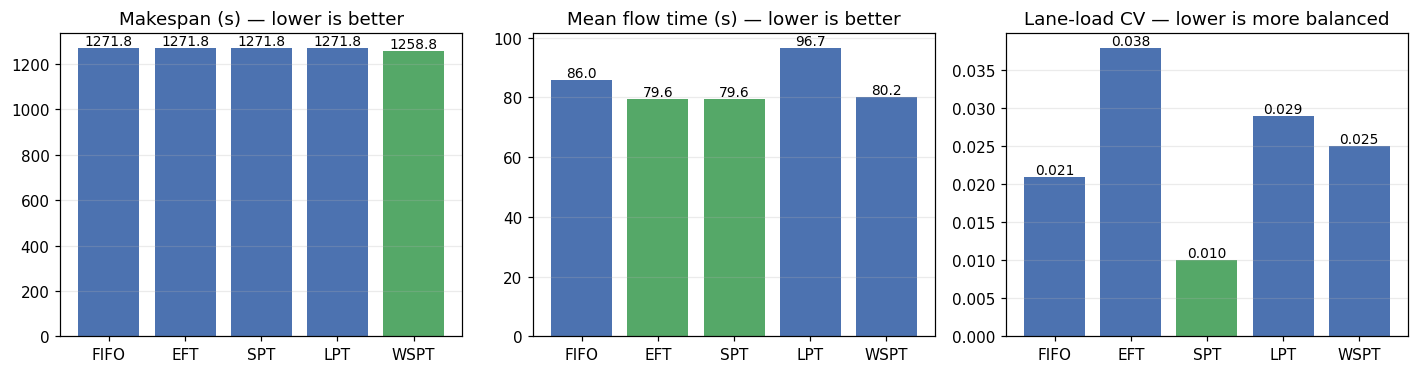

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col, title in zip(
    axes,
    ['makespan_s', 'mean_flow_s', 'lane_balance_cv'],
    ['Makespan (s) — lower is better', 'Mean flow time (s) — lower is better', 'Lane-load CV — lower is more balanced']
):
    best = summary[col].min()
    colors = ['#55a868' if v == best else '#4c72b0' for v in summary[col]]
    ax.bar(summary['rule'], summary[col], color=colors)
    for i, v in enumerate(summary[col]):
        ax.text(i, v, f'{v:.1f}' if col != 'lane_balance_cv' else f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9)
    ax.set_title(title); ax.grid(alpha=0.25, axis='y')
plt.tight_layout(); plt.savefig('rule_comparison.png', dpi=130); plt.show()

## 3. Inspect a single rule's schedule (Gantt)

WSPT delivered the lowest makespan; let's see what its schedule looks like on each lane.

In [6]:
rule_name = 'WSPT'
schedule = RULES[rule_name](totes, num_lanes)
sched_df = schedule.to_dataframe()
sched_df.head()

,tote_id,lane,release,start,finish,processing,wait,flow,priority,grade
0,T001,1,34.30,34.30,95.30,61.00,0.00,61.00,1,Express
1,T002,2,34.30,34.30,63.40,29.10,0.00,29.10,1,Express
2,T003,3,57.70,57.70,135.60,77.90,0.00,77.90,1,Standard
3,T004,4,59.40,59.40,145.90,86.50,0.00,86.50,2,Standard
4,T005,2,61.00,63.40,81.00,17.60,2.40,20.00,2,Standard


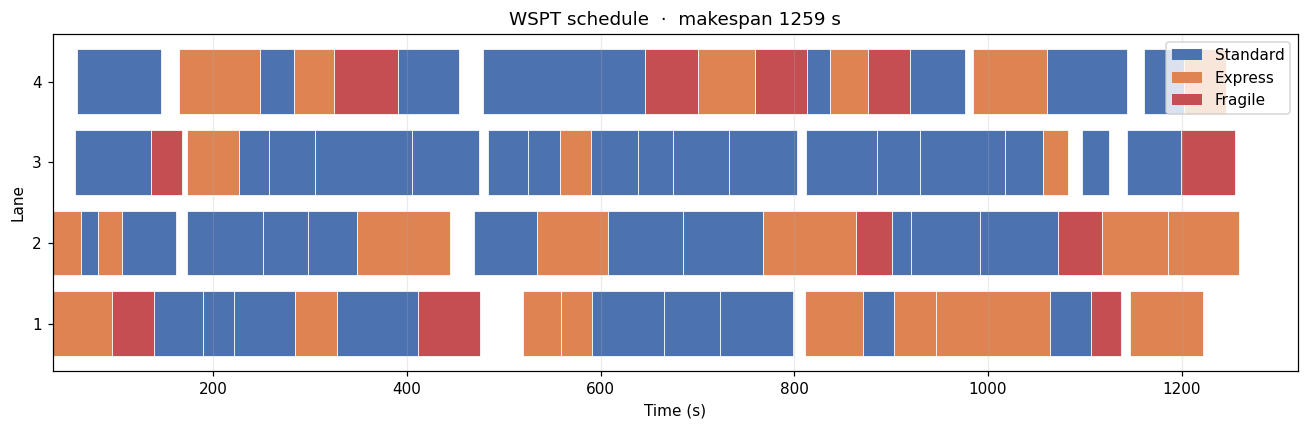

In [7]:
from matplotlib.patches import Patch

def plot_gantt(schedule, title='', ax=None):
    df = schedule.to_dataframe()
    grade_color = {'Standard': '#4c72b0', 'Express': '#dd8452', 'Fragile': '#c44e52'}
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    for _, row in df.iterrows():
        ax.barh(row['lane'], row['finish'] - row['start'], left=row['start'],
                color=grade_color.get(row['grade'], '#888'),
                edgecolor='white', linewidth=0.5)
    ax.set_yticks(sorted(df['lane'].unique()))
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Lane'); ax.set_title(title)
    ax.grid(alpha=0.25, axis='x')
    return ax

fig, ax = plt.subplots(figsize=(12, 4))
plot_gantt(schedule, title=f'{rule_name} schedule  ·  makespan {schedule.makespan:.0f} s', ax=ax)
ax.legend(handles=[Patch(facecolor='#4c72b0', label='Standard'),
                    Patch(facecolor='#dd8452', label='Express'),
                    Patch(facecolor='#c44e52', label='Fragile')], loc='upper right')
plt.tight_layout(); plt.savefig('gantt_wspt.png', dpi=130); plt.show()

## 4. Side-by-side Gantt — same workload, different rules

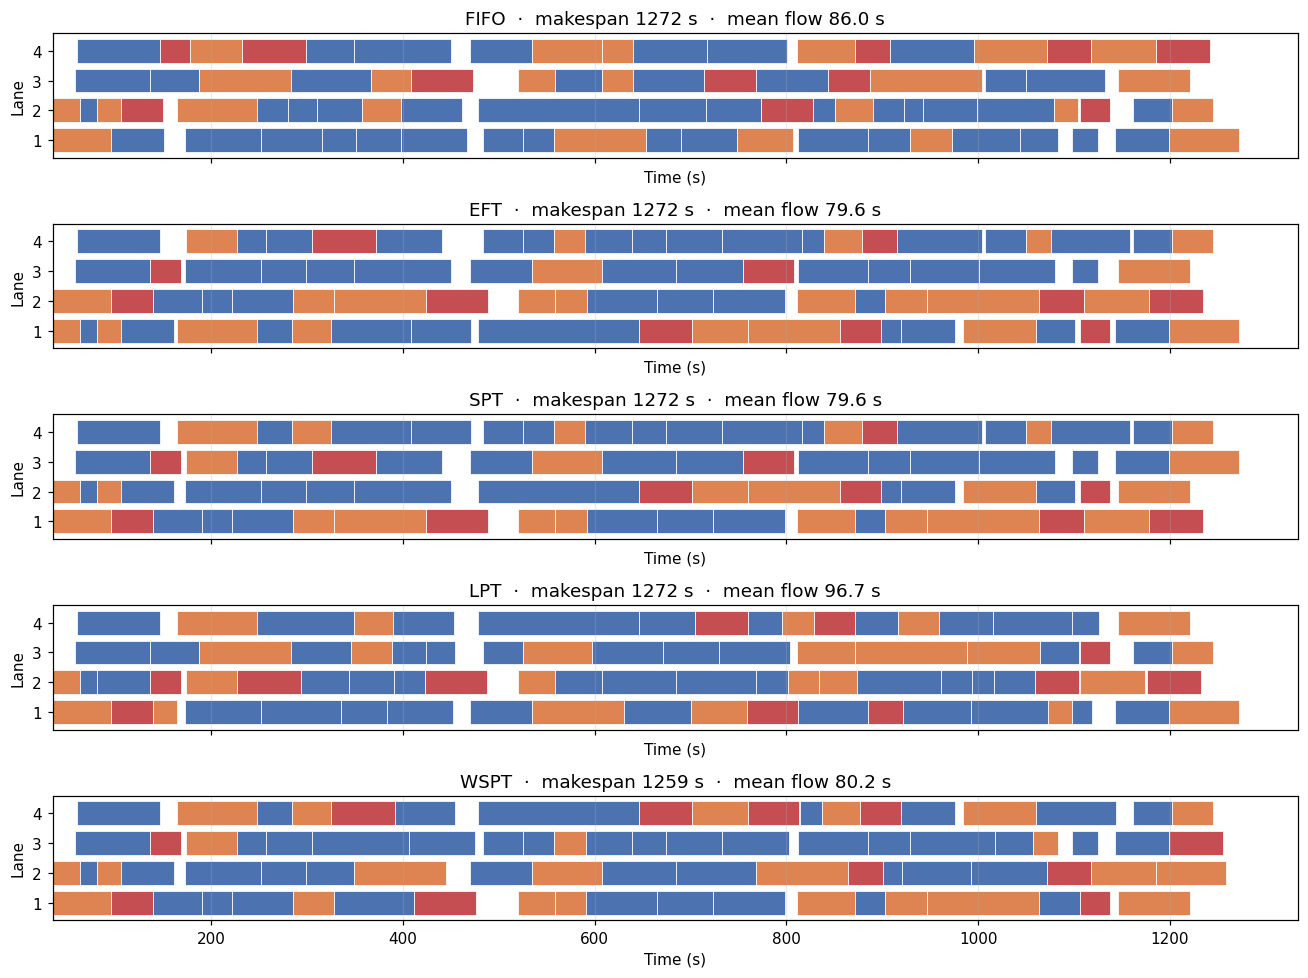

In [8]:
fig, axes = plt.subplots(len(RULES), 1, figsize=(12, 1.8 * len(RULES)), sharex=True)
for ax, (rule, fn) in zip(axes, RULES.items()):
    s = fn(totes, num_lanes)
    plot_gantt(s, ax=ax, title=f'{rule}  ·  makespan {s.makespan:.0f} s  ·  mean flow {s.mean_flow_time:.1f} s')
plt.tight_layout(); plt.savefig('gantt_comparison.png', dpi=130); plt.show()

## Summary

- **WSPT** delivers the lowest makespan (1,259 s vs. 1,272 s for the rest) by exercising the priority lever — high-priority short jobs go first, freeing lanes for the long tail.
- **SPT** and **EFT** tie for lowest mean flow time (~79 s) — they aggressively push short jobs through, minimising average tote-cycle time.
- **LPT** is *worst* on flow time (~97 s) — long jobs hog the lanes early, leaving short jobs to wait — but it's the standard textbook recommendation when you only care about makespan and have non-zero release times.
- **SPT** also delivers the most balanced lane utilisation (CV 0.010), useful when uneven wear or staffing matters.

Run [conveyor_scheduling_app.py](conveyor_scheduling_app.py) for the interactive dashboard — edit the tote list and lane count, switch rules, and see the Gantt update in real time.